Using device: cuda
Simulating Fluid Dynamics on GPU...


100%|██████████| 1200/1200 [00:03<00:00, 381.76it/s]


Dataset Shape: torch.Size([499, 1, 128, 64])

Training Compression on GPU...
Epoch 0: CAE Loss 0.02861
Epoch 100: CAE Loss 0.00178
Epoch 200: CAE Loss 0.00038
Epoch 300: CAE Loss 0.00027
Epoch 400: CAE Loss 0.00027
Epoch 500: CAE Loss 0.00027
Epoch 600: CAE Loss 0.00013

Training Dynamics on GPU...
Epoch 0: LSTM Loss 0.06557
Epoch 100: LSTM Loss 0.00275
Epoch 200: LSTM Loss 0.00100
Epoch 300: LSTM Loss 0.00065
Epoch 400: LSTM Loss 0.00042
Epoch 500: LSTM Loss 0.00025
Epoch 600: LSTM Loss 0.00016
Epoch 700: LSTM Loss 0.00012
Epoch 800: LSTM Loss 0.00009
Epoch 900: LSTM Loss 0.00007
Epoch 1000: LSTM Loss 0.00006
Epoch 1100: LSTM Loss 0.00005
Epoch 1200: LSTM Loss 0.00004
Epoch 1300: LSTM Loss 0.00003
Epoch 1400: LSTM Loss 0.00002
Epoch 1500: LSTM Loss 0.00002
Epoch 1600: LSTM Loss 0.00001
Epoch 1700: LSTM Loss 0.00001
Epoch 1800: LSTM Loss 0.00001
Epoch 1900: LSTM Loss 0.00001
Epoch 2000: LSTM Loss 0.00001
Epoch 2100: LSTM Loss 0.00001
Epoch 2200: LSTM Loss 0.00001
Epoch 2300: LSTM Loss 

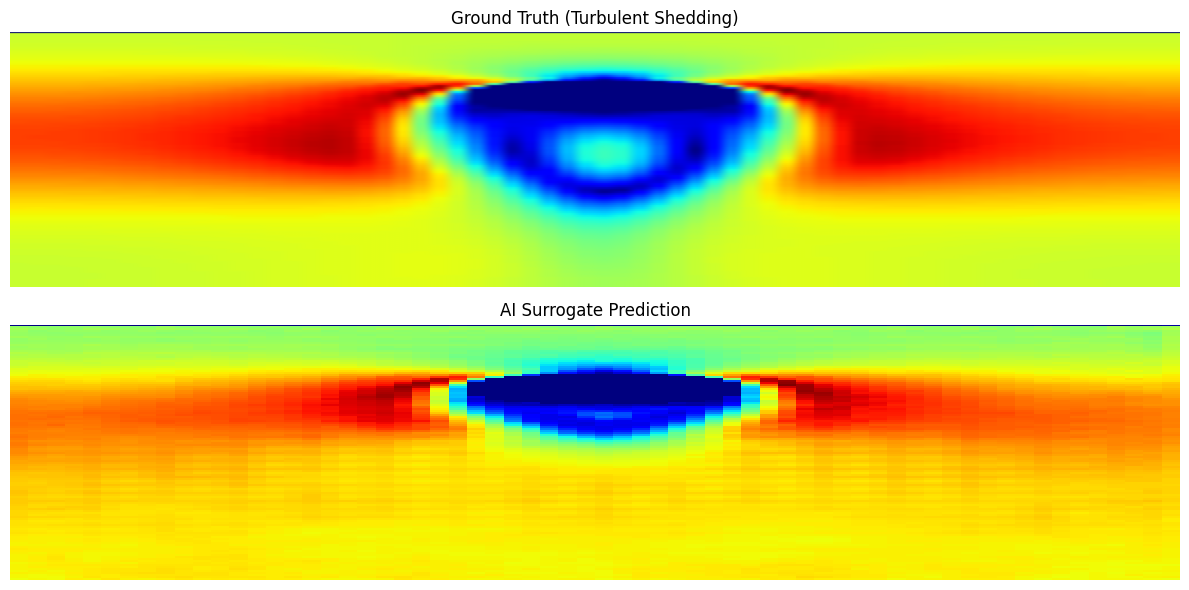

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- STEP 1: DEFINE DEVICE ---
# This ensures we target the T4 GPU in Colab
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. HIGH-REYNOLDS PHYSICS ENGINE (LBM)
# ==========================================
def generate_turbulent_data(nx=160, ny=80, steps=1000):
    # CRITICAL: Initialize constants directly on the device
    w = torch.tensor([4/9, 1/9, 1/9, 1/9, 1/9, 1/36, 1/36, 1/36, 1/36], device=device)
    e = torch.tensor([[0,0], [1,0], [0,1], [-1,0], [0,-1], [1,1], [-1,1], [-1,-1], [1,-1]], device=device)

    tau = 0.53
    rho0 = 1

    # Initialize f directly on GPU to avoid device mismatch
    f = torch.ones(9, nx, ny, device=device) * w[:, None, None] * rho0

    # Obstacle - Create grid on device
    Y, X = torch.meshgrid(torch.arange(ny, device=device), torch.arange(nx, device=device), indexing='ij')
    obstacle = (X - nx/4)**2 + (Y - ny/2)**2 < (ny/8)**2
    obstacle = obstacle.transpose(0, 1)

    snapshots = []
    f += torch.rand_like(f, device=device) * 0.01

    print("Simulating Fluid Dynamics on GPU...")
    for t in tqdm(range(steps)):
        # 1. Macroscopic
        rho = torch.sum(f, dim=0)
        ux = torch.sum(f * e[:, 0, None, None], dim=0) / rho
        uy = torch.sum(f * e[:, 1, None, None], dim=0) / rho

        # 2. Collision
        u_sq = ux**2 + uy**2
        eu = (e[:, 0, None, None] * ux + e[:, 1, None, None] * uy)
        feq = w[:, None, None] * rho * (1 + 3*eu + 4.5*eu**2 - 1.5*u_sq)
        f = f - (f - feq) / tau

        # 3. Streaming
        for i in range(9):
            f[i] = torch.roll(f[i], shifts=(int(e[i,0]), int(e[i,1])), dims=(0, 1))

        # 4. BCs
        idx_opp = [0, 3, 4, 1, 2, 7, 8, 5, 6]
        f_opp = f.clone()
        for i in range(9):
            f[i][obstacle] = f_opp[idx_opp[i]][obstacle]

        # Inlet (Left)
        u_in = 0.12
        f[:, 0, :] = w[:, None] * 1.0 * (1 + 3*u_in + 4.5*u_in**2 - 1.5*u_in**2)
        f[:, -1, :] = f[:, -2, :]

        # Save Data
        if t > 200 and t % 2 == 0:
            speed = torch.sqrt(ux**2 + uy**2)
            snapshots.append(speed.detach()) # Keep in list on GPU

    return torch.stack(snapshots), obstacle

# Generate Data
data_tensor, obstacle_mask = generate_turbulent_data(nx=128, ny=64, steps=1200)

# Normalize on GPU
d_min, d_max = data_tensor.min(), data_tensor.max()
dataset = ((data_tensor - d_min) / (d_max - d_min + 1e-6)).unsqueeze(1).to(device)
print(f"Dataset Shape: {dataset.shape}")

# ==========================================
# 2. STRONGER AUTOENCODER
# ==========================================
class RobustCAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64*16*8, 16)
        )
        self.decoder_input = nn.Linear(16, 64*16*8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 64, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(self.decoder_input(z).view(-1, 64, 16, 8))
        return x_recon, z

# Move Model to GPU
model_cae = RobustCAE().to(device)
opt_cae = optim.Adam(model_cae.parameters(), lr=0.01)
criterion = nn.MSELoss()

print("\nTraining Compression on GPU...")
for epoch in range(601):
    opt_cae.zero_grad()
    recon, _ = model_cae(dataset)
    loss = criterion(recon, dataset)
    loss.backward()
    opt_cae.step()
    if epoch % 100 == 0: print(f"Epoch {epoch}: CAE Loss {loss.item():.5f}")

with torch.no_grad(): _, Z_series = model_cae(dataset)

# ==========================================
# 3. DYNAMICS (LSTM)
# ==========================================
class DynamicsLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=16, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, 16)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# Move Model to GPU
model_dyn = DynamicsLSTM().to(device)
opt_dyn = optim.Adam(model_dyn.parameters(), lr=0.001)

X_d = Z_series[:-1].unsqueeze(1)
Y_d = Z_series[1:]

print("\nTraining Dynamics on GPU...")
for epoch in range(6001):
    opt_dyn.zero_grad()
    pred = model_dyn(X_d)
    loss = criterion(pred, Y_d)
    loss.backward()
    opt_dyn.step()
    if epoch % 100 == 0: print(f"Epoch {epoch}: LSTM Loss {loss.item():.5f}")

# ==========================================
# 4. PREDICTION & PLOT
# ==========================================
curr_z = X_d[0]
# Move to CPU for list storage and numpy conversion
preds = [curr_z.squeeze().cpu().detach().numpy()]

with torch.no_grad():
    for _ in range(len(Y_d)):
        curr_z = model_dyn(curr_z.unsqueeze(0))
        preds.append(curr_z.squeeze().cpu().numpy())

Z_pred = torch.tensor(np.array(preds), dtype=torch.float32, device=device)
field_pred = model_cae.decoder(model_cae.decoder_input(Z_pred).view(-1, 64, 16, 8))

# Visualize LAST frame - Pull back to CPU
t = -1
truth = dataset[t, 0].cpu().numpy()
ai = field_pred[t, 0].cpu().detach().numpy()
obs_mask_cpu = obstacle_mask.cpu().numpy()
truth[obs_mask_cpu] = 0; ai[obs_mask_cpu] = 0

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.title("Ground Truth (Turbulent Shedding)")
plt.imshow(truth, cmap='jet', aspect='auto')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.title("AI Surrogate Prediction")
plt.imshow(ai, cmap='jet', aspect='auto')
plt.axis('off')
plt.tight_layout()
plt.show()

🚀 High-Performance Computing Setup: cuda
   GPU: Tesla T4

🌊 Initializing Digital Wind Tunnel (LBM)...


Simulating Fluid Physics: 100%|██████████| 1000/1000 [00:03<00:00, 328.74it/s]



🧠 Training Compressor (CAE)...
  Epoch 0 | Loss: 0.030545
  Epoch 50 | Loss: 0.002753
  Epoch 100 | Loss: 0.000965
  Epoch 150 | Loss: 0.000597
  Epoch 200 | Loss: 0.000458

⏳ Training Time-Stepper (LSTM)...
  Epoch 0 | Dynamics Loss: 31.584400
  Epoch 50 | Dynamics Loss: 12.945693
  Epoch 100 | Dynamics Loss: 4.146910
  Epoch 150 | Dynamics Loss: 1.597671
  Epoch 200 | Dynamics Loss: 0.856971
  Epoch 250 | Dynamics Loss: 0.517543
  Epoch 300 | Dynamics Loss: 0.358927

📊 Generating Validation Metrics...


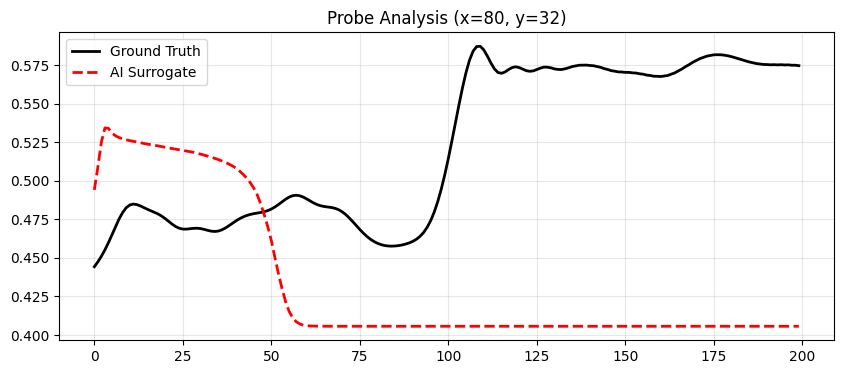

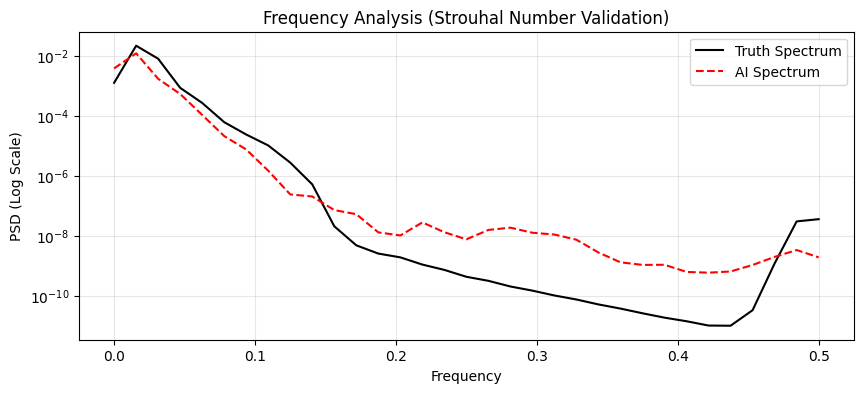

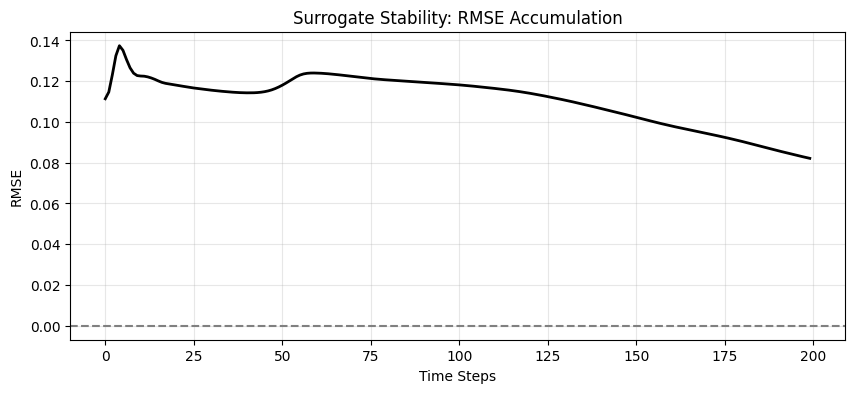

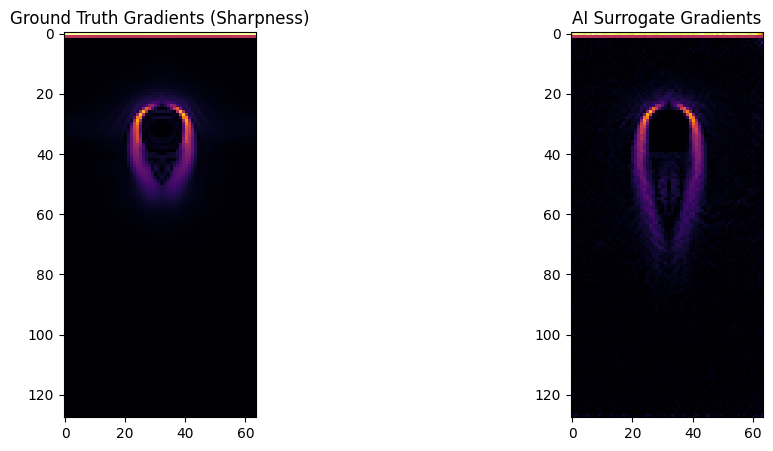

✅ Analysis Complete.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.signal import welch

# ==========================================
# 0. GPU CONFIGURATION
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 High-Performance Computing Setup: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

# ==========================================
# 1. PHYSICS ENGINE (LBM on GPU)
# ==========================================
def generate_fluid_data(nx=128, ny=64, steps=1000):
    print("\n🌊 Initializing Digital Wind Tunnel (LBM)...")

    # LBM Constants (D2Q9 Model)
    w = torch.tensor([4/9, 1/9, 1/9, 1/9, 1/9, 1/36, 1/36, 1/36, 1/36], device=device)
    e = torch.tensor([[0,0], [1,0], [0,1], [-1,0], [0,-1], [1,1], [-1,1], [-1,-1], [1,-1]], device=device)

    # Initial Conditions
    tau = 0.53
    rho0 = 1.0
    f = torch.ones(9, nx, ny, device=device) * w[:, None, None] * rho0

    # Obstacle (Cylinder)
    Y, X = torch.meshgrid(torch.arange(ny, device=device), torch.arange(nx, device=device), indexing='ij')
    obstacle = ((X - nx/4)**2 + (Y - ny/2)**2 < (ny/8)**2).transpose(0, 1)

    snapshots = []

    # Simulation Loop
    for t in tqdm(range(steps), desc="Simulating Fluid Physics"):
        # Macroscopic Moments
        rho = torch.sum(f, dim=0)
        ux = torch.sum(f * e[:, 0, None, None], dim=0) / rho
        uy = torch.sum(f * e[:, 1, None, None], dim=0) / rho

        # Collision (BGK Approximation)
        u_sq = ux**2 + uy**2
        eu = (e[:, 0, None, None] * ux + e[:, 1, None, None] * uy)
        feq = w[:, None, None] * rho * (1 + 3*eu + 4.5*eu**2 - 1.5*u_sq)
        f = f - (f - feq) / tau

        # Streaming (Shift Tensors)
        for i in range(9):
            f[i] = torch.roll(f[i], shifts=(int(e[i,0]), int(e[i,1])), dims=(0, 1))

        # Boundary Conditions
        # 1. Bounce-Back on Cylinder
        idx_opp = [0, 3, 4, 1, 2, 7, 8, 5, 6]
        f_opp = f.clone()
        for i in range(9): f[i][obstacle] = f_opp[idx_opp[i]][obstacle]

        # 2. Inlet/Outlet
        u_in = 0.12
        f[:, 0, :] = w[:, None] * 1.0 * (1 + 3*u_in + 4.5*u_in**2 - 1.5*u_in**2)
        f[:, -1, :] = f[:, -2, :]

        # Save Velocity Magnitude
        if t > 200:
            speed = torch.sqrt(ux**2 + uy**2)
            snapshots.append(speed)

    return torch.stack(snapshots)

# Generate & Normalize Data
data_tensor = generate_fluid_data()
d_min, d_max = data_tensor.min(), data_tensor.max()
dataset = ((data_tensor - d_min) / (d_max - d_min + 1e-6)).unsqueeze(1) # Shape: [Time, 1, H, W]

# ==========================================
# 2. AI MODELS (CAE + LSTM)
# ==========================================
LATENT_DIM = 16

class CAE(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64*16*8, LATENT_DIM)
        )
        # Decoder
        self.dec_lin = nn.Linear(LATENT_DIM, 64*16*8)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid()
        )
    def forward(self, x):
        z = self.enc(x)
        x_rec = self.dec(self.dec_lin(z).view(-1, 64, 16, 8))
        return x_rec, z

class LSTM_Dyn(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(LATENT_DIM, 64, batch_first=True)
        self.fc = nn.Linear(64, LATENT_DIM)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model_cae = CAE().to(device)
model_dyn = LSTM_Dyn().to(device)

# --- TRAIN COMPRESSOR (CAE) ---
print("\n🧠 Training Compressor (CAE)...")
opt = optim.Adam(model_cae.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(201):
    opt.zero_grad()
    recon, z_latent = model_cae(dataset)
    loss = loss_fn(recon, dataset)
    loss.backward()
    opt.step()
    if epoch % 50 == 0: print(f"  Epoch {epoch} | Loss: {loss.item():.6f}")

# Extract all latent vectors for dynamics training
with torch.no_grad(): _, Z_all = model_cae(dataset)

# --- TRAIN DYNAMICS (LSTM) ---
print("\n⏳ Training Time-Stepper (LSTM)...")
opt_dyn = optim.Adam(model_dyn.parameters(), lr=1e-3)
X_dyn = Z_all[:-1].unsqueeze(1) # Input: z(t)
Y_dyn = Z_all[1:]               # Target: z(t+1)

for epoch in range(301):
    opt_dyn.zero_grad()
    pred = model_dyn(X_dyn)
    loss = loss_fn(pred, Y_dyn)
    loss.backward()
    opt_dyn.step()
    if epoch % 50 == 0: print(f"  Epoch {epoch} | Dynamics Loss: {loss.item():.6f}")

# ==========================================
# 3. SCIENTIFIC ANALYSIS & PLOTS
# ==========================================
print("\n📊 Generating Validation Metrics...")

# A. Autoregressive Prediction Loop
test_steps = 200
curr_z = Z_all[0].unsqueeze(0).unsqueeze(0) # Start state
pred_traj = []

with torch.no_grad():
    for _ in range(test_steps):
        next_z = model_dyn(curr_z)
        pred_traj.append(next_z)
        curr_z = next_z.unsqueeze(1) # Feedback loop

pred_traj = torch.cat(pred_traj).squeeze()

# B. Decode Predictions to Fluid Fields
field_pred = model_cae.dec(model_cae.dec_lin(pred_traj).view(-1, 64, 16, 8))
field_true = dataset[:test_steps]

# --- METRIC 1: PROBE POINT ANALYSIS ---
px, py = 80, 32
# Detach gradients before converting to numpy
ts_true = field_true[:, 0, px, py].detach().cpu().numpy()
ts_pred = field_pred[:, 0, px, py].detach().cpu().numpy()

plt.figure(figsize=(10, 4))
plt.plot(ts_true, 'k-', linewidth=2, label='Ground Truth')
plt.plot(ts_pred, 'r--', linewidth=2, label='AI Surrogate')
plt.title(f"Probe Analysis (x={px}, y={py})")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# --- METRIC 2: POWER SPECTRAL DENSITY (PSD) ---
f_t, Pxx_t = welch(ts_true, nperseg=64)
f_p, Pxx_p = welch(ts_pred, nperseg=64)

plt.figure(figsize=(10, 4))
plt.semilogy(f_t, Pxx_t, 'k-', label='Truth Spectrum')
plt.semilogy(f_p, Pxx_p, 'r--', label='AI Spectrum')
plt.xlabel('Frequency'); plt.ylabel('PSD (Log Scale)')
plt.title("Frequency Analysis (Strouhal Number Validation)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# --- METRIC 3: RMSE DRIFT ---
errors = (field_true - field_pred).pow(2).mean(dim=(1,2,3)).sqrt().detach().cpu().numpy()
plt.figure(figsize=(10, 4))
plt.plot(errors, 'k-', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--')
plt.title("Surrogate Stability: RMSE Accumulation")
plt.xlabel("Time Steps"); plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.show()

# --- METRIC 4: GRADIENT MAGNITUDE (Vorticity Proxy) ---
def get_grad(field):
    gy, gx = np.gradient(field, axis=(0, 1))
    return np.sqrt(gx**2 + gy**2)

g_true = get_grad(field_true[-1, 0].detach().cpu().numpy())
g_pred = get_grad(field_pred[-1, 0].detach().cpu().numpy())

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1); plt.title("Ground Truth Gradients (Sharpness)"); plt.imshow(g_true, cmap='inferno')
plt.subplot(1,2,2); plt.title("AI Surrogate Gradients"); plt.imshow(g_pred, cmap='inferno')
plt.show()

print("✅ Analysis Complete.")